### UROP Research Log — July 12, 2026

### Objective
Finalize Stage 2 results with comparison table and visualizations,
and design the Stage 3 IV-RV spread dynamic switching algorithm.

### Stage 2 Final Results
Three-component TE decomposition (annualized, 2022):

| Component | Annual | Share |
|-----------|--------|-------|
| VWAP Slippage (Model A vs B) | -1.41% | 55% |
| Expense Ratio | -0.29% | 11% |
| Execution Residual | -0.87% | 34% |
| Total (PBP vs Model B) | -2.57% | 100% |

Check: VWAP Slippage + TE_A = TE_B (exact) 
Consistency: Stage 1 alpha (-1.44%) ≈ Stage 2 TE_A (-1.16%) 

In [ ]:
# -- Stage 1 vs Stage 2 Final Comparison --
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
from scipy import stats

# -- Summary Table --
summary = {
    'Metric': [
        'Data Source (PBP)',
        'BXM Reference',
        'Timestamp',
        'Observations',
        'Ann. TE (std)',
        'R²',
        'Beta',
        'Alpha (annualized)',
        'Mean TE / period',
    ],
    'Stage 1 (Baseline)': [
        'Nasdaq close',
        'BXM_History.csv',
        '4:00 PM vs ~4:15 PM',
        '251 days',
        '4.80%',
        '0.9171',
        '0.9826',
        '-1.10%',
        '-0.0072%',
    ],
    'Stage 1 (Expiry-to-Expiry)': [
        'Cboe EOD mid_1545',
        'BXM_History.csv',
        '15:45 ET (PBP) vs 4:15 PM (BXM)',
        '11 periods',
        '0.93%',
        '0.9963',
        '1.0053',
        '-1.44%',
        '-0.1197%',
    ],
    'Stage 2 (Model A/B)': [
        'Cboe EOD mid_1545',
        'SPX_1545 + SOQ settlement',
        '15:45 ET (both)',
        '11 periods',
        '2.12% (Model A)',
        'N/A',
        'N/A',
        'TE_A: -1.16% / TE_B: -2.57%',
        'TE_A: -0.0965% / TE_B: -0.2139%',
    ],
}

df_summary = pd.DataFrame(summary)
print("=== Stage 1 vs Stage 2 Final Comparison ===\n")
print(df_summary.to_string(index=False))

=== Stage 1 vs Stage 2 Final Comparison ===

            Metric  Stage 1 (Baseline)      Stage 1 (Expiry-to-Expiry)             Stage 2 (Model A/B)
 Data Source (PBP)        Nasdaq close               Cboe EOD mid_1545               Cboe EOD mid_1545
     BXM Reference     BXM_History.csv                 BXM_History.csv       SPX_1545 + SOQ settlement
         Timestamp 4:00 PM vs ~4:15 PM 15:45 ET (PBP) vs 4:15 PM (BXM)                 15:45 ET (both)
      Observations            251 days                      11 periods                      11 periods
     Ann. TE (std)               4.80%                           0.93%                 2.12% (Model A)
                R²              0.9171                          0.9963                             N/A
              Beta              0.9826                          1.0053                             N/A
Alpha (annualized)              -1.10%                          -1.44%     TE_A: -1.16% / TE_B: -2.57%
  Mean TE / period          

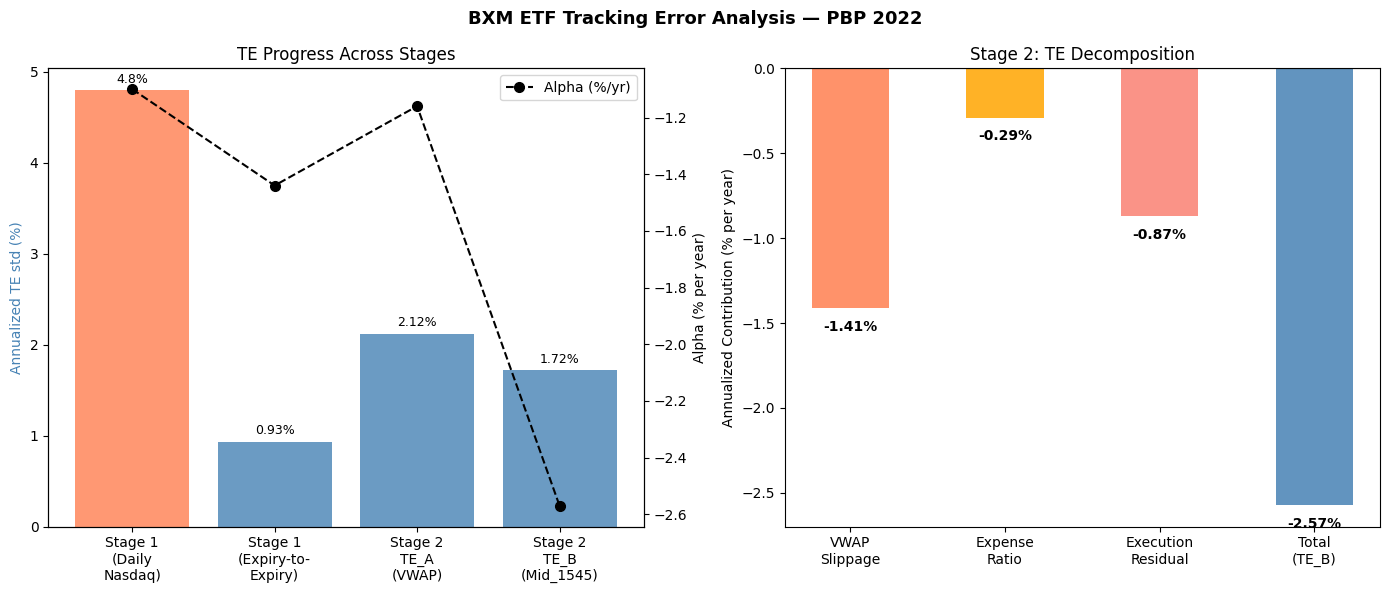

Saved.


In [2]:
# -- Final TE Decomposition Visualization --

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -- Plot 1: TE Progression (Stage 1 → Stage 2) --
ax = axes[0]
stages = ['Stage 1\n(Daily\nNasdaq)', 'Stage 1\n(Expiry-to-\nExpiry)', 'Stage 2\nTE_A\n(VWAP)', 'Stage 2\nTE_B\n(Mid_1545)']
te_stds = [4.80, 0.93, 2.12, 1.72]
alphas  = [-1.10, -1.44, -1.16, -2.57]
colors  = ['coral', 'steelblue', 'steelblue', 'steelblue']

bars = ax.bar(stages, te_stds, color=colors, alpha=0.8)
ax.set_ylabel('Annualized TE std (%)', color='steelblue')
ax.set_title('TE Progress Across Stages')

ax2 = ax.twinx()
ax2.plot(stages, alphas, 'ko--', linewidth=1.5, markersize=7, label='Alpha (%/yr)')
ax2.set_ylabel('Alpha (% per year)', color='black')
ax2.legend(loc='upper right')

for bar, val in zip(bars, te_stds):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05,
            f'{val}%', ha='center', va='bottom', fontsize=9)

# -- Plot 2: TE Decomposition Waterfall --
ax = axes[1]
components  = ['VWAP\nSlippage', 'Expense\nRatio', 'Execution\nResidual', 'Total\n(TE_B)']
values      = [-1.41, -0.29, -0.87, -2.57]
colors_bar  = ['coral', 'orange', 'salmon', 'steelblue']

bars = ax.bar(components, values, color=colors_bar, alpha=0.85, width=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Annualized Contribution (% per year)')
ax.set_title('Stage 2: TE Decomposition')

for bar, val in zip(bars, values):
    ypos = val - 0.07 if val < 0 else val + 0.03
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:.2f}%', ha='center', va='top' if val < 0 else 'bottom',
            fontsize=10, fontweight='bold')

plt.suptitle('BXM ETF Tracking Error Analysis — PBP 2022',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("../data/processed/stage2_final_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

### Stage 3 Design: IV-RV Spread Dynamic Switching

### Research Question
Can switching between BXM (ATM call) and BXMD (30-delta call) based on
the IV-RV spread improve risk-adjusted returns vs static BXM?

### Theoretical Basis
Bakshi & Kapadia (2003): IV systematically exceeds RV for SPX options.
The magnitude of IV-RV spread determines how richly options are priced.
When spread is large → options overpriced → sell ATM (BXM, more premium)
When spread is small → options fairly priced → sell 30-delta (BXMD, less risk)

Kumiega et al. (2024): BXMC (conditional BXM/BXMH based on VIX > 20)
outperforms static BXM on Return-to-Risk basis (0.5875 vs 0.4629).
Our approach generalizes this using IV-RV spread instead of VIX level.

### Switching Rule
At each roll date t:
- Compute IV_t = trade_iv of ATM call at 15:45 ET (from Cboe tick data)
- Compute RV_t = 21-day rolling realized volatility of SPX returns
- Spread_t = IV_t - RV_t

If Spread_t > threshold → sell ATM call (BXM strategy)
If Spread_t <= threshold → sell 30-delta call (BXMD strategy)

### Implementation Plan
Step 1: Extract daily IV at 15:45 ET
- Load all 251 daily tick files
- Filter to SPX monthly calls, ATM strike, 15:45 ET
- Extract trade_iv from last trade before 15:46

Step 2: Compute 21-day rolling RV
- Use SPX daily log returns from BXM_History.csv or SPX_Bloomberg_2022.csv
- RV = annualized std of last 21 daily log returns

Step 3: Compute IV-RV spread time series
- Plot daily spread to identify regimes
- Determine threshold (0 or empirical)

Step 4: Identify 30-delta strike at each roll date
- From Cboe tick data: find strike where trade_delta ≈ 0.30 at 15:45 ET
- Extract mid_1545 for that strike

Step 5: Dynamic portfolio returns
- Apply switching rule at each roll date
- Compute expiry-to-expiry returns for dynamic strategy
- Compare vs static BXM and BXMD

Step 6: Performance comparison
- Annualized return, std, Sharpe ratio
- Compare: Static BXM / Static BXMD / Dynamic switching
- Per Kumiega et al. (2024) Table 7 format

### Data Already Available
- Cboe SPX options tick data (251 files, 2022) ✅
- SPX daily returns (BXM_History.csv or SPX_Bloomberg_2022.csv) ✅
- BXMD_Bloomberg_2022.csv for validation ✅